In [3]:
import pandas as pd
import pymc as pm
import japanize_matplotlib
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import numpy as np
import arviz as az

In [9]:
df = pd.read_csv("../data/telco_churn_survival.csv")
df["is_one_year"] = (df["Contract"] == "One year").astype(int)
df["is_two_year"] = (df["Contract"] == "Two year").astype(int)
df

,customerID,tenure,Churn,Contract,MonthlyCharges,gender,SeniorCitizen,event,is_one_year,is_two_year
0,7590-VHVEG,1,No,Month-to-month,29.85,Female,0,0,0,0
1,5575-GNVDE,34,No,One year,56.95,Male,0,0,1,0
2,3668-QPYBK,2,Yes,Month-to-month,53.85,Male,0,1,0,0
3,7795-CFOCW,45,No,One year,42.30,Male,0,0,1,0
4,9237-HQITU,2,Yes,Month-to-month,70.70,Female,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,No,One year,84.80,Male,0,0,1,0
7039,2234-XADUH,72,No,One year,103.20,Female,0,0,1,0
7040,4801-JZAZL,11,No,Month-to-month,29.60,Female,0,0,0,0
7041,8361-LTMKD,4,Yes,Month-to-month,74.40,Male,1,1,0,0


In [10]:
t_obs_safe = df["tenure"].values.astype(float) + 0.5
event_obs = df["event"].values.astype(float)
x1 = df["is_one_year"].values.astype(float)
x2 = df["is_two_year"].values.astype(float)
n = len(df)

breaks = np.arange(0, 78, 6)
n_intervals = len(breaks) - 1
interval_idx = np.searchsorted(breaks, t_obs_safe, side="right") - 1
interval_idx = np.clip(interval_idx, 0, n_intervals - 1)
exposure = t_obs_safe - breaks[interval_idx]


In [52]:
with pm.Model() as cox_model:

    h0 = pm.Gamma("h0", alpha=10, beta=10/0.055, shape=n_intervals)

    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    log_hazard_ratio = beta1 * x1 + beta2 * x2
    h_i = h0[interval_idx] * pt.exp(log_hazard_ratio)

    log_lik = event_obs * pt.log(h_i) - h_i * exposure
    pm.Potential("loglike", pt.sum(log_lik))

In [53]:
with cox_model:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
    

/tmp/ipykernel_68736/758012488.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [beta1, beta2, h0]


In [54]:
h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
beta1_prior = prior.prior["beta1"].values.reshape(-1, n_intervals)
beta2_prior = prior.prior["beta2"].values.reshape(-1, n_intervals)

print("h0 (区間別ベースラインハザード) の事前分布:")
for k in range(n_intervals):
    print(f"  区間{k}({breaks[k]}-{breaks[k+1]}ヶ月): 平均={h0_prior[:,k].mean():.4f}")

print("\nbeta1(1年契約): 平均=", beta1_prior.mean(), "sd=", beta1_prior.std())
print("beta2(2年契約): 平均=", beta2_prior.mean(), "sd=", beta2_prior.std())

print("\nハザード比 exp(beta1)の範囲:", np.percentile(np.exp(beta1_prior), [5, 50, 95]))
print("\nハザード比 exp(beta2)の範囲:", np.percentile(np.exp(beta2_prior), [5, 50, 95]))

h0 (区間別ベースラインハザード) の事前分布:
  区間0(0-6ヶ月): 平均=0.0553
  区間1(6-12ヶ月): 平均=0.0538
  区間2(12-18ヶ月): 平均=0.0549
  区間3(18-24ヶ月): 平均=0.0550
  区間4(24-30ヶ月): 平均=0.0547
  区間5(30-36ヶ月): 平均=0.0543
  区間6(36-42ヶ月): 平均=0.0545
  区間7(42-48ヶ月): 平均=0.0548
  区間8(48-54ヶ月): 平均=0.0551
  区間9(54-60ヶ月): 平均=0.0577
  区間10(60-66ヶ月): 平均=0.0556
  区間11(66-72ヶ月): 平均=0.0543

beta1(1年契約): 平均= -0.07602711994291339 sd= 1.0489068370607706
beta2(2年契約): 平均= -0.008127980823314495 sd= 1.0890935456926116

ハザード比 exp(beta1)の範囲: [0.18300807 0.83581057 5.11389325]

ハザード比 exp(beta2)の範囲: [0.20509996 0.94967847 5.59054963]


In [55]:
#カプランマイヤー曲線
def kaplan_meier(t_obs, event_obs):
    order = np.argsort(t_obs)
    t_sorted = t_obs[order]
    e_sorted = event_obs[order]
    unique_times = np.unique(t_sorted[e_sorted == 1])

    survival = 1.0
    km_times= [0]
    km_surv = [1.0]
    n_at_risk = len(t_obs)

    for t in unique_times:
        n_event = np.sum((t_sorted == t) & (e_sorted == 1))
        n_at_risk = np.sum(t_sorted >= t)
        survival *= (1 - n_event / n_at_risk)
        km_times.append(t)
        km_surv.append(survival)

    return np.array(km_times), np.array(km_surv)

km_t, km_s = kaplan_meier(t_obs_safe, event_obs)

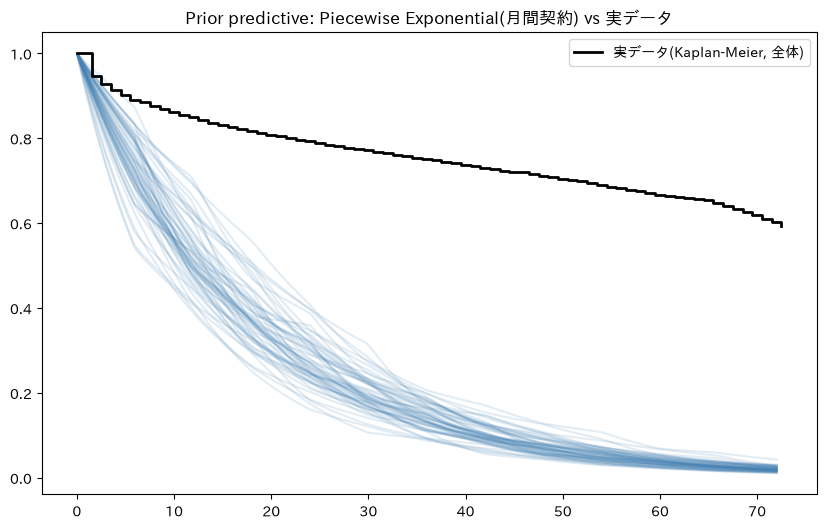

In [56]:
def piecewise_survival(t_range, h0_vals, breaks):
    S = np.ones_like(t_range)
    cum_hazard = np.zeros_like(t_range)
    for i, t in enumerate(t_range):
        idx = np.searchsorted(breaks, t, side="right") -1
        idx = np.clip(idx, 0, len(h0_vals)-1)

        ch = sum(h0_vals[k] * (breaks[k+1]-breaks[k]) for k in range(idx))
        ch += h0_vals[idx] * (t - breaks[idx])
        cum_hazard[i] = ch
    return np.exp(-cum_hazard)

t_range = np.linspace(0.1, 72, 100)
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(60):
    S_baseline = piecewise_survival(t_range, h0_prior[i], breaks)
    ax.plot(t_range, S_baseline, color="steelblue", alpha=0.15)

ax.step(km_t, km_s, where="post", color="black", lw=2, label="実データ(Kaplan-Meier, 全体)")
ax.legend()
ax.set_title("Prior predictive: Piecewise Exponential(月間契約) vs 実データ")
plt.savefig("../img/cox_prior_check.png", dpi=100)


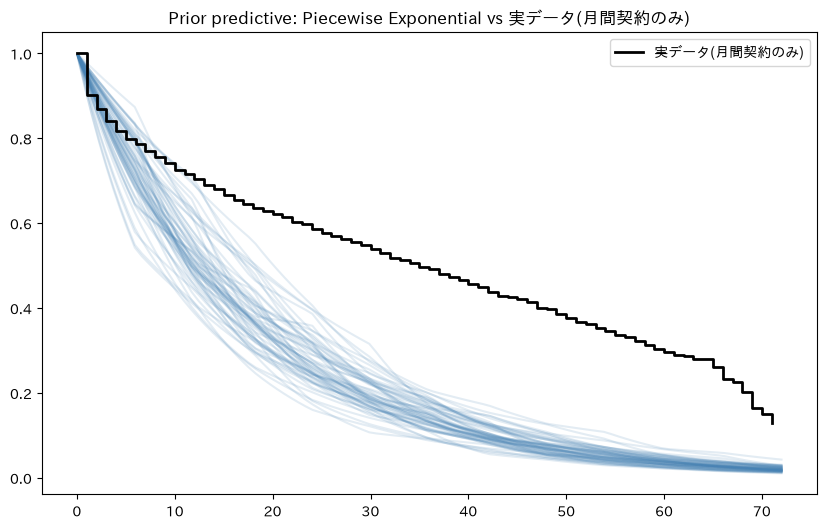

In [57]:
df_month = df[df["Contract"]=="Month-to-month"]
km_t_month, km_s_month = kaplan_meier(
    df_month["tenure"].values.astype(float), 
    df_month["event"].values.astype(float)
)

fig, ax = plt.subplots(figsize=(10,6))
for i in range(60):
    S_baseline = piecewise_survival(t_range, h0_prior[i], breaks)
    ax.plot(t_range, S_baseline, color="steelblue", alpha=0.15)

ax.step(km_t_month, km_s_month, where="post", color="black", lw=2, label="実データ(月間契約のみ)")
ax.legend()
ax.set_title("Prior predictive: Piecewise Exponential vs 実データ(月間契約のみ)")
plt.savefig("../img/cox_prior_check_v2.png", dpi=100)

In [39]:
df_month = df[df["Contract"] == "Month-to-month"]
df_month["tenure"].describe()

count    3875.000000
mean       18.036645
std        17.689054
min         1.000000
25%         3.000000
50%        12.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64

In [58]:
with cox_model:
    idata_cox = pm.sample(
        draws=2000, tune=2000, chains=4, target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

NUTS[numpyro]: [h0, beta1, beta2]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%|                                     | 0/4000 [00:00<?, ?it/s]

  0%|                                                   | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                     | 0/4000 [00:00<?, ?it/s]


  0%|                                                   | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                  | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|                                  | 0/4000 [00:01<?, ?it/s]


Running chain 0:   5%|█▏                     | 200/4000 [00:01<00:03, 996.94it/s]

Running chain 2:   5%|█▏                     | 200/4000 [00:01<00:04, 906.97it/s]


Running chain 0:  10%|██▏                   | 400/4000 [00:01<00:02, 1209.15it/s]


Running chain 3:  10%|██▏                   | 400/4000 [00:01<00:03, 1172.75it/s]

Running chain 0:  15

In [60]:
print("divergences:", int(idata_cox.sample_stats["diverging"].sum()))
az.summary(idata_cox, var_names=["h0", "beta1", "beta2"])                          

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
h0[0],0.1974,0.0074,0.19,0.21,9401,6277,1.00,7.6e-05,5.4e-05
h0[1],0.1334,0.0082,0.12,0.15,9111,6024,1.00,8.6e-05,6.2e-05
h0[2],0.1348,0.0096,0.12,0.15,9474,5595,1.00,9.8e-05,7.1e-05
h0[3],0.1007,0.0089,0.087,0.12,9207,6414,1.00,9.2e-05,6.4e-05
h0[4],0.0997,0.0096,0.085,0.12,9258,6038,1.00,9.9e-05,7.1e-05
h0[5],0.0961,0.0096,0.081,0.11,9804,6199,1.00,9.7e-05,6.8e-05
h0[6],0.1025,0.0109,0.086,0.12,9040,6284,1.00,0.00011,8.1e-05
h0[7],0.0962,0.0113,0.079,0.12,9095,6432,1.00,0.00012,8.7e-05
h0[8],0.0954,0.0114,0.078,0.11,9125,6323,1.00,0.00012,8.6e-05
h0[9],0.1004,0.0123,0.081,0.12,8233,5874,1.00,0.00013,9.8e-05


In [61]:
beta1_post = idata_cox.posterior["beta1"].values.flatten()
beta2_post = idata_cox.posterior["beta2"].values.flatten()
print("\nハザード比 exp(beta1)[1年契約]:", np.percentile(np.exp(beta1_post), [5,50,95]))
print("ハザード比 exp(beta2)[2年契約]:", np.percentile(np.exp(beta2_post), [5,50,95]))


ハザード比 exp(beta1)[1年契約]: [0.31379959 0.36179872 0.41349023]
ハザード比 exp(beta2)[2年契約]: [0.06416564 0.08411195 0.10939557]
